# Loss Given Default, Exposure at Default and Expected Loss

**Loss given default (LGD)**  

LGD is the proportion of the total exposure at the time borrower defaults. 

**Exposure at default (EAD)**  

EAD is the  amount of loss at default.  

**Models used**

+ LGD: can be Beta regression or Linear regression. Here we split into 2 steps: 1st is Logreg, 2nd is Linear regression
+ EAD: can be Beta regression or Linear regression. Here we use Linear regression

**Data**

Use only accounts with loan status: charge off, not meet credit policy,.. (not take into account non-default borrowers)

Xs: same as PD model

Y:

Y for LGD model is Recovery rate (use Recoveries column). 

LGD = 1 - RR

RR = recoveries/ total funded amount. RR belongs [0,1]

Y for EAD model: 

EAD = CCF * total funded 

CCF = (total funded - total recoveries principal)/ total funded

If CCF = 0 then EAD = 0 -> all paid

If CCF = 1 then EAD = total funded -> all lost

**I. LGD model**

Stage 1: Logistic regression, to check if recovery rate (RR) is 0 or not

+ Prepare inputs
+ Test model
+ Estimate accuracy, use ROC..

Stage 2: Multiple linear regression, to estimate recovery rate

+ LR
+ Estimate
+ Evaluate; how well regression perform by or (1) calculate corr (actual, predicted value). If that value is too high -> question our methodology; (2) distribution of the difference btw actual vs predicted values. The residual should be close to normal dist.

Combine 2 stages: multiply predicted values from 2 stages


**II. EAD model**

+ Estimate: Use LR to investigate dist of CCF. 

Interpret: (+) coef: same direction with CCF; (-) coef: negative direction with CCF

i.e: if coef of IR feature in the regression = -0.0117, then 1% increase in IR -> expect CCF decreases by 1.17%

+ Validate: evaluate how well moel predict CCF, use:

(1) corr method: corr (actual, predicted) > 0.35: moderate strong
(2) dist of residual: should close to normal dist

**III. Expected loss EL**

EL =  PD x EAD  x LGD

EL: we consider loss of all customers:

we calculate: % (total EL/ total funded)

## Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import roc_curve, roc_auc_score
import scipy.stats as stat

#export model
import pickle

#export user-defined functions
%run Userdefined_functions.ipynb

## Import Data

In [2]:
#import data
df1 = pd.read_csv("loan_data_inputs_train.csv", index_col = 0)
df2 = pd.read_csv("loan_data_inputs_test.csv", index_col = 0)
loan_data_preprocessed  = pd.concat([df1,df2],axis=0) #'loan_data_2007_2014_preprocessed.csv')
df1, df2 = [], [] #deleting the df s that use a large amount of ram source

## Filtering defaulted account data

In [13]:
# We only need the data on the accounts that were charged-off (written-off).
loan_data_defaults = loan_data_preprocessed[loan_data_preprocessed['loan_status'].\
                                            isin(['Charged Off','Does not meet the credit policy. Status:Charged Off'])]
loan_data_defaults = loan_data_defaults.copy()

In [14]:
loan_data_defaults.shape

(43236, 313)

## Independent Variables

In [15]:
# # Let's fill missing values with zeroes.
loan_data_defaults['mths_since_last_delinq'].fillna(0, inplace = True)

# loan_data_defaults.loc[:, 'mths_since_last_delinq'] = loan_data_defaults['mths_since_last_delinq'].fillna(0)

In [16]:
# Let's fill the missing values with zeroes.
loan_data_defaults['mths_since_last_record'].fillna(0, inplace=True)

## Dependent Variables
###  Recovery rate

In [17]:
# For the LGD model, We need to calculate the dependent variable recovery rate.
# It is the ratio of recoveries and funded amount.
loan_data_defaults['recovery_rate'] = loan_data_defaults['recoveries'] / loan_data_defaults['funded_amnt']

In [18]:
# Let's check out some descriptive statisics for the values of a column.
loan_data_defaults['recovery_rate'].describe()

count    43236.000000
mean         0.060820
std          0.089770
min          0.000000
25%          0.000000
50%          0.029466
75%          0.114044
max          1.220774
Name: recovery_rate, dtype: float64

In [19]:
# We have some recovery rate data > 1.0.
# We need to set recovery rates that are greater than 1 to 1 
loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] > 1, 1, loan_data_defaults['recovery_rate'])
# We need to set recovery rates that are less than 0 to 0. (this part is kept for a future dataset)
loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] < 0, 0, loan_data_defaults['recovery_rate'])


In [20]:
#let's check if all is good after data cleaning
loan_data_defaults['recovery_rate'].describe()

count    43236.000000
mean         0.060770
std          0.089202
min          0.000000
25%          0.000000
50%          0.029466
75%          0.114044
max          1.000000
Name: recovery_rate, dtype: float64

### CCF

In [21]:
# let's calculate the dependent variable for the EAD model: credit conversion factor.
# It is the ratio of the difference of the amount used at the moment of default to the total funded amount.
loan_data_defaults['CCF'] = (loan_data_defaults['funded_amnt'] - \
                             loan_data_defaults['total_rec_prncp']) / loan_data_defaults['funded_amnt']


In [22]:
loan_data_defaults['CCF'].describe()
# Shows some descriptive statisics for the values of a column.

count    43236.000000
mean         0.735952
std          0.200742
min          0.000438
25%          0.632088
50%          0.789908
75%          0.888543
max          1.000000
Name: CCF, dtype: float64

(array([  10.,   21.,   49.,   21.,   51.,   54.,   21.,  103.,   30.,
          93.,   73.,   62.,   96.,   63.,  135.,   99.,  116.,  145.,
         125.,  162.,  140.,  178.,  162.,  178.,  213.,  194.,  228.,
         209.,  258.,  248.,  275.,  263.,  295.,  326.,  372.,  312.,
         409.,  367.,  382.,  420.,  454.,  475.,  528.,  525.,  515.,
         573.,  554.,  655.,  636.,  718.,  742.,  861.,  809.,  965.,
         873., 1105., 1033., 1182., 1130., 1270., 1317., 1360., 1477.,
        1327., 1715., 1457., 1803., 1463., 1874., 1520., 1393., 1568.,
         750.,  999.,  652.]),
 array([4.38000000e-04, 1.37654933e-02, 2.70929867e-02, 4.04204800e-02,
        5.37479733e-02, 6.70754667e-02, 8.04029600e-02, 9.37304533e-02,
        1.07057947e-01, 1.20385440e-01, 1.33712933e-01, 1.47040427e-01,
        1.60367920e-01, 1.73695413e-01, 1.87022907e-01, 2.00350400e-01,
        2.13677893e-01, 2.27005387e-01, 2.40332880e-01, 2.53660373e-01,
        2.66987867e-01, 2.80315360e-01, 2

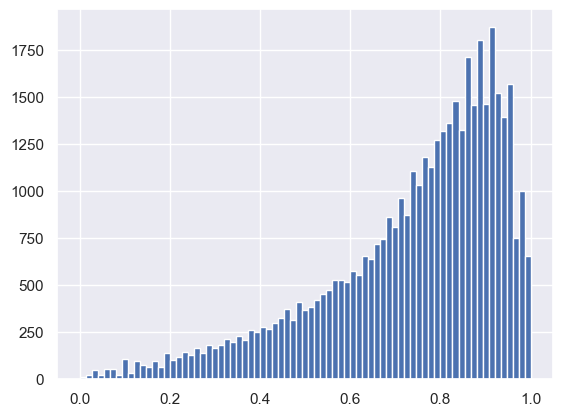

In [23]:
# Plotting a histogram of CCF
plt.hist(loan_data_defaults['CCF'], bins = 75)

In [24]:
# Creating a new variable showing 0 for recovery rate being 0 and 1 otherwise.
loan_data_defaults['recovery_rate_0_1'] = np.where(loan_data_defaults['recovery_rate'] == 0, 0, 1)

## Exporting data

In [25]:
#saving the data in a csv file
loan_data_defaults.to_csv('loan_data_defaults.csv')

## I.  LGD Model

LGD is the amount outstanding we expect to lose. It is a proportion of the total exposure when borrower defaults. 

The model will be implemented in two steps:
*  Stage 1- recovery rate is equal to/greater than 0

*  Stage 2- recovery rate is equal to/greater than 1

### Step 1 - Logistic Regression

In [26]:
# LGD model step 1 datasets: recovery rate 0 or greater than 0.
# Considering a set of inputs [all cols except recovery rate and CCF] and outputs[recovery_rate_0_1]. Splits the inputs and the targets into four dataframes:
# Inputs - Train n Test, Targets - Train n Test
lgd_X_S1 = loan_data_defaults.drop([ 'recovery_rate','recovery_rate_0_1', 'CCF'], axis = 1)
lgs_Y_S1 = loan_data_defaults['recovery_rate_0_1']

lgd_X_S1_train, lgd_X_S1_test, lgd_Y_S1_train, lgd_Y_S1_test = train_test_split(lgd_X_S1, lgs_Y_S1, test_size = 0.2, random_state = 42)

In [27]:
# List of all X variables for the models.
features_all = ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:MORTGAGE',
'home_ownership:NONE',
'home_ownership:OTHER',
'home_ownership:OWN',
'home_ownership:RENT',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:car',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:educational',
'purpose:home_improvement',
'purpose:house',
'purpose:major_purchase',
'purpose:medical',
'purpose:moving',
'purpose:other',
'purpose:renewable_energy',
'purpose:small_business',
'purpose:vacation',
'purpose:wedding',
'initial_list_status:f',
'initial_list_status:w',
'term_int',
'emp_length_int',
'mths_since_issue_d',
'mths_since_earliest_cr_line',
'funded_amnt',
'int_rate',
'installment',
'annual_inc',
'dti',
'delinq_2yrs',
'inq_last_6mths',
'mths_since_last_delinq',
'mths_since_last_record',
'open_acc',
'pub_rec',
'total_acc',
'acc_now_delinq',
'total_rev_hi_lim']

In [28]:
features_reference_cat = ['grade:G',
'home_ownership:RENT',
'verification_status:Verified',
'purpose:credit_card',
'initial_list_status:f']

lgd_X_S1_train = lgd_X_S1_train[features_all]
# Remove the dummy variable reference categories
lgd_X_S1_train = lgd_X_S1_train.drop(features_reference_cat, axis = 1)

In [29]:
lgd_X_S1_train.isnull().sum()
# Check for missing values. We check whether the value of each row for each column is missing or not,
# then sum accross columns.

grade:A                                0
grade:B                                0
grade:C                                0
grade:D                                0
grade:E                                0
grade:F                                0
home_ownership:MORTGAGE                0
home_ownership:NONE                    0
home_ownership:OTHER                   0
home_ownership:OWN                     0
verification_status:Not Verified       0
verification_status:Source Verified    0
purpose:car                            0
purpose:debt_consolidation             0
purpose:educational                    0
purpose:home_improvement               0
purpose:house                          0
purpose:major_purchase                 0
purpose:medical                        0
purpose:moving                         0
purpose:other                          0
purpose:renewable_energy               0
purpose:small_business                 0
purpose:vacation                       0
purpose:wedding 

In [30]:
# We create an instance of an object from the 'LogisticRegression' class.
reg_lgd_st_1 = LogisticRegression_with_p_values()

# Estimating the coefficients of the object from the 'LogisticRegression' class
# with X (independent variables) from the first dataframe
# and Y (dependent variables) from the second dataframe.
reg_lgd_st_1.fit(lgd_X_S1_train, lgd_Y_S1_train)


C:\Users\Admin\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
# Stores the names of the columns of a dataframe in a variable.
feature_name = lgd_X_S1_train.columns.values

In [32]:
# Creating a df with a column 'Feature name' and values of the 'feature_name' variable.
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
# Creates a new column called 'Coefficients',
# with row values the transposed coefs from the 'LogisticRegression' object.
summary_table['Coefficients'] = np.transpose(reg_lgd_st_1.coef_)
# Increasing the index of every row of the df with 1.
summary_table.index = summary_table.index + 1
# Assigning values of the row with index 0 of the df.
summary_table.loc[0] = ['Intercept', reg_lgd_st_1.intercept_[0]]
# Sorts the df by index.
summary_table = summary_table.sort_index()
# We take the result of the newly added method 'p_values' and store it in a variable 'p_values'.
p_values = reg_lgd_st_1.p_values
# We add the value 'NaN' in the beginning of the variable with p-values.
p_values = np.append(np.nan,np.array(p_values))
# In the 'summary_table' df, we add a new column, called 'p_values', containing the values from the 'p_values' variable.
summary_table['p_values'] = p_values

summary_table

,Feature name,Coefficients,p_values
0,Intercept,-8.109826e-05,NaN
1,grade:A,-1.784427e-05,9.998330e-01
2,grade:B,-6.594708e-05,9.992320e-01
3,grade:C,-1.249203e-04,9.984856e-01
4,grade:D,1.168451e-05,9.998636e-01
5,grade:E,3.166258e-05,9.996646e-01
6,grade:F,7.347590e-05,9.993251e-01
7,home_ownership:MORTGAGE,-4.543506e-05,9.985820e-01
8,home_ownership:NONE,1.285595e-06,9.999989e-01
9,home_ownership:OTHER,1.147946e-06,9.999979e-01


### Step 1 - Test the model

In [33]:
# Keep only the variables [features_all] that we need for the model
lgd_X_S1_test = lgd_X_S1_test[features_all]
# Remove the dummy variable reference categories.
lgd_X_S1_test = lgd_X_S1_test.drop(features_reference_cat, axis = 1)

In [34]:
# Calculating the predicted vals for the Y (targets) given X (inputs)
y_hat_test_lgd_step_1 = reg_lgd_st_1.model.predict(lgd_X_S1_test)

y_hat_test_lgd_step_1

array([0, 1, 1, ..., 1, 1, 1])

In [35]:
# Calculates the predicted probability for Y (targets) given X (inputs)
y_hat_test_proba_lgd_step_1 = reg_lgd_st_1.model.predict_proba(lgd_X_S1_test)

# arrays of predicted class probabilities
# first value: probability for the observation belonging to the first class  (Y= 0)
# second value: probability for the observation belonging to 1
y_hat_test_proba_lgd_step_1

array([[0.56074825, 0.43925175],
       [0.40487383, 0.59512617],
       [0.38201617, 0.61798383],
       ...,
       [0.43472196, 0.56527804],
       [0.35297824, 0.64702176],
       [0.37926114, 0.62073886]])

In [36]:
# Consider only the probabilities for being 1
y_hat_test_proba_lgd_step_1 = y_hat_test_proba_lgd_step_1[: ][: , 1]
y_hat_test_proba_lgd_step_1

array([0.43925175, 0.59512617, 0.61798383, ..., 0.56527804, 0.64702176,
       0.62073886])

In [37]:
lgd_Y_S1_test_temp = lgd_Y_S1_test
# resetting the index of a dataframe.
lgd_Y_S1_test_temp.reset_index(drop = True, inplace = True)

In [38]:
# Concatenating two dataframes.
df_actual_predicted_probs = pd.concat([lgd_Y_S1_test_temp, pd.DataFrame(y_hat_test_proba_lgd_step_1)], axis = 1)
df_actual_predicted_probs.columns = ['lgd_targets_step_1_test', 'y_hat_test_proba_lgd_step_1']
df_actual_predicted_probs.index = lgd_X_S1_test.index

df_actual_predicted_probs.head()

,lgd_targets_step_1_test,y_hat_test_proba_lgd_step_1
273771,1,0.439252
353045,0,0.595126
437319,0,0.617984
193344,1,0.644176
173478,0,0.674073


### Step 1 - Estimating the Аccuracy 

In [39]:
tr = 0.5
# Indicator column created to give '1' for the cases where predicted proba is greater than threshold
df_actual_predicted_probs['y_hat_test_lgd_step_1'] = np.where(df_actual_predicted_probs['y_hat_test_proba_lgd_step_1'] > tr, 1, 0)

# Creating a cross-table, a Confusion Matrix where the actual vals are displayed by rows and the predicted vals by columns.
pd.crosstab(df_actual_predicted_probs['lgd_targets_step_1_test'], df_actual_predicted_probs['y_hat_test_lgd_step_1'], rownames = ['Actual'], colnames = ['Predicted'])

Predicted,0,1
Actual,,
0,1203,2615
1,885,3945


In [40]:
# Get rates by dividing values by the tot number of observations,
cmatrix_p = pd.crosstab(df_actual_predicted_probs['lgd_targets_step_1_test'], \
                        df_actual_predicted_probs['y_hat_test_lgd_step_1'], \
                        rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]
cmatrix_p

Predicted,0,1
Actual,,
0,0.139107,0.302382
1,0.102336,0.456175


In [41]:
# Calculating accuracy of the model = sum of the diagonal rates.
cmatrix_p.iloc[0, 0] + cmatrix_p.iloc[1, 1]

0.5952821461609621

Text(0.5, 1.0, 'ROC curve')

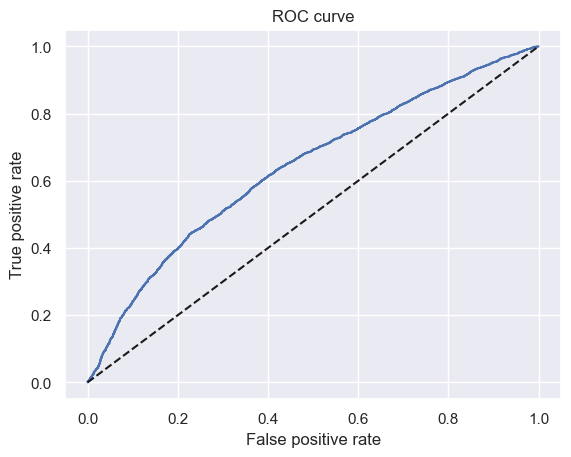

In [42]:
# Getting Receiver Operating Characteristic (ROC) Curve: the false positive rates, the true positive rates, and the thresholds.
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['lgd_targets_step_1_test'], df_actual_predicted_probs['y_hat_test_proba_lgd_step_1'])

# We plot the ROC: false positive rate along the x-axis and the true positive rate along the y-axis,
plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

In [43]:
# Calculating the Area Under the Receiver Operating Characteristic Curve (AUROC)
AUROC = roc_auc_score(df_actual_predicted_probs['lgd_targets_step_1_test'], df_actual_predicted_probs['y_hat_test_proba_lgd_step_1'])
AUROC

0.6401912266945178

ROC being 0.64 shows a better performance of 1:1 line, a random model of probability of 0.50. Hence, we keep the model.

In [44]:
# Exporting our model to a 'SAV' file
pickle.dump(reg_lgd_st_1, open('lgd_model_step_1.sav', 'wb'))

### Step 2 - Linear Regression

In [45]:
# Here we take only rows where the original recovery rate variable is greater than one,
# i.e. where the indicator variable we created is equal to 1.
lgd_step_2_data = loan_data_defaults[loan_data_defaults['recovery_rate_0_1'] == 1]

In [46]:
# LGD model stage 2 datasets: how much more than 0 is the recovery rate
lgd_X_S2 = lgd_step_2_data.drop([ 'recovery_rate','recovery_rate_0_1', 'CCF'], axis = 1)
lgd_Y_S2 = lgd_step_2_data['recovery_rate']
# splitting Inputs - Train + Test and  Targets - Train + Test.
lgd_X_S2_train, lgd_X_S2_test, lgd_Y_S2_train, lgd_Y_S2_test = train_test_split(lgd_X_S2, lgd_Y_S2, test_size = 0.2, random_state = 42)
# freeing the memory used by following arrays
lgd_x_S2, lgd_Y_S2  = [],[]

In [47]:
# keeping the variables needed for the model.
lgd_X_S2_train = lgd_X_S2_train[features_all]
# removing the dummy variable reference categories.
lgd_X_S2_train = lgd_X_S2_train.drop(features_reference_cat, axis = 1)

In [48]:
#we call LinearRegression() from file of user-defined-functions or we run code below

# class LinearRegression(linear_model.LinearRegression):
#     """
#     LinearRegression class after sklearn's, but calculate t-statistics
#     and p-values for model coefficients (betas).
#     Additional attributes available after .fit()
#     are `t` and `p` which are of the shape (y.shape[1], X.shape[1])
#     which is (n_features, n_coefs)
#     This class sets the intercept to 0 by default, since usually we include it
#     in X.
#     """
    
#     # nothing changes in __init__
#     def __init__(self, fit_intercept=True, copy_X=True,
#                  n_jobs=1): #normalize=False
#         super().__init__(fit_intercept=fit_intercept, copy_X=copy_X, n_jobs=n_jobs ) #normalize=normalize)
#         self.fit_intercept = fit_intercept
# #         self.normalize = normalize
#         self.copy_X = copy_X
#         self.n_jobs = n_jobs

    
#     def fit(self, X, y, n_jobs=1):
#         self = super(LinearRegression, self).fit(X, y, n_jobs)
        
#         # Calculate SSE (sum of squared errors)
#         # and SE (standard error)
#         sse = np.sum((self.predict(X) - y) ** 2, axis=0) / float(X.shape[0] - X.shape[1])
#         se = np.array([np.sqrt(np.diagonal(sse * np.linalg.inv(np.dot(X.T, X))))])

#         # compute the t-statistic for each feature
#         self.t = self.coef_ / se
#         # find the p-value for each feature
#         self.p = np.squeeze(2 * (1 - stat.t.cdf(np.abs(self.t), y.shape[0] - X.shape[1])))
#         return self


In [49]:
# creating an instance of an object from the 'LinearRegression' class.
reg_lgd_st_2 = LinearRegression()
# Estimating the coeffs w X_train and Y_train
reg_lgd_st_2.fit(lgd_X_S2_train, lgd_Y_S2_train)

LinearRegression()

In [50]:
# Storing the names of the columns
feature_name = lgd_X_S2_train.columns.values

In [51]:
# Creating a df with a column 'Feature name' and vals in 'feature_name'
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
# Creating a new column 'Coefficients' w row values the transposed coefficients from the 'LogisticRegression' object.
summary_table['Coefficients'] = np.transpose(reg_lgd_st_2.coef_)
# Increasing the index of every row of the dataframe with 1.
summary_table.index = summary_table.index + 1
# Assigning values of the row with index 0 of the dataframe.
summary_table.loc[0] = ['Intercept', reg_lgd_st_2.intercept_]
# Sorting the dataframe by index.
summary_table = summary_table.sort_index()
# Taking the result of the newly added method 'p_values' and store it in a variable 'p_values'.
p_values = reg_lgd_st_2.p
# Adding the value 'NaN' in the beginning of the variable with p-values.
p_values = np.append(np.nan,np.array(p_values))
# Adding a column of 'p_values', containing the values
summary_table['p_values'] = p_values.round(3)

summary_table

,Feature name,Coefficients,p_values
0,Intercept,2.596884e-01,NaN
1,grade:A,-8.542627e-02,0.000
2,grade:B,-6.188063e-02,0.000
3,grade:C,-4.839424e-02,0.000
4,grade:D,-3.485896e-02,0.000
5,grade:E,-1.903644e-02,0.000
6,grade:F,-1.049845e-02,0.029
7,home_ownership:MORTGAGE,2.436369e-03,0.101
8,home_ownership:NONE,1.435086e-01,0.000
9,home_ownership:OTHER,5.398011e-02,0.007


### Step 2 - Model Evaluation

In [52]:
# keeping the variables needed
lgd_X_S2_test = lgd_X_S2_test[features_all]

# Removing the dummy variable reference categories.
lgd_X_S2_test = lgd_X_S2_test.drop(features_reference_cat, axis = 1)

# Predicting Y given X
y_hat_test_lgd_step_2 = reg_lgd_st_2.predict(lgd_X_S2_test)

lgd_Y_S2_test_temp = lgd_Y_S2_test

# Resetting the index of a dataframe.
lgd_Y_S2_test_temp = lgd_Y_S2_test_temp.reset_index(drop = True)

# Calculating the correlation between actual and predicted values.
pd.concat([lgd_Y_S2_test_temp, pd.DataFrame(y_hat_test_lgd_step_2)], axis = 1).corr()


,recovery_rate,0
recovery_rate,1.000000,0.286862
0,0.286862,1.000000


<Axes: xlabel='recovery_rate', ylabel='Count'>

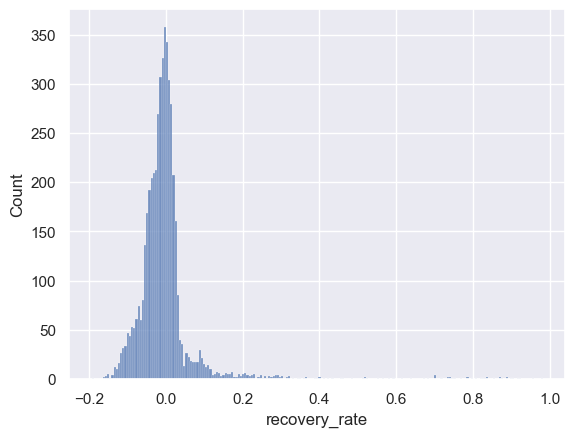

In [53]:
# Plotting the distribution of the residuals.
sns.histplot(lgd_Y_S2_test_temp - y_hat_test_lgd_step_2)

In [54]:
# Here we export our model
pickle.dump(reg_lgd_st_2, open('lgd_model_step_2.sav', 'wb'))

### Combining Stages 1 & 2

In [55]:
y_hat_test_lgd_step_2_all = reg_lgd_st_2.predict(lgd_X_S1_test)
# y_hat_test_lgd_step_2_all

In [56]:
# combining the predictions of the models from the two steps.y_hat_test_proba_lgd_step_1: multiplication the results
y_hat_test_lgd = y_hat_test_lgd_step_1 * y_hat_test_lgd_step_2_all 

# Showing descriptive stats 
pd.DataFrame(y_hat_test_lgd).describe()


,0
count,8648.000000
mean,0.081082
std,0.052044
min,-0.004608
25%,0.031443
50%,0.097587
75%,0.120525
max,0.240395


In [57]:
y_hat_test_lgd = np.where(y_hat_test_lgd < 0, 0, y_hat_test_lgd)
y_hat_test_lgd = np.where(y_hat_test_lgd > 1, 1, y_hat_test_lgd)
# We set predicted values that are greater than 1 to 1 and predicted values that are less than 0 to 0.

In [58]:
pd.DataFrame(y_hat_test_lgd).describe()
# Shows some descriptive statisics for the values of a column.

,0
count,8648.000000
mean,0.081083
std,0.052042
min,0.000000
25%,0.031443
50%,0.097587
75%,0.120525
max,0.240395


## II. EAD Model
### Linear modeling and interpreation

In [59]:
# EAD model datasets
# Splitting into Inputs - Train n Test, Targets - Train n Test.
ead_X = loan_data_defaults.drop([ 'recovery_rate','recovery_rate_0_1', 'CCF'], axis = 1)
ead_Y = loan_data_defaults['CCF']
ead_X_train, ead_X_test, ead_Y_train, ead_Y_test = train_test_split(ead_X, ead_Y, test_size = 0.2, random_state = 42)
ead_X, ead_Y = [],[]

In [60]:
ead_X_train.columns.values

array(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'veri

In [61]:
# Keep only the variables needed and remove reference categories.
ead_X_train = ead_X_train[features_all]
ead_X_train = ead_X_train.drop(features_reference_cat, axis = 1)

In [62]:
# Create an instance of an object from the 'LinearRegression' class.
reg_ead = LinearRegression()
# Estimates the coefficients of the object from the 'LogisticRegression' class
# with inputs (independent variables) contained in the first dataframe
# and targets (dependent variables) contained in the second dataframe.
reg_ead.fit(ead_X_train, ead_Y_train)

LinearRegression()

In [63]:
feature_name = ead_X_train.columns.values

In [64]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg_ead.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg_ead.intercept_]
summary_table = summary_table.sort_index()
p_values = reg_ead.p
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,1.093109e+00,NaN
1,grade:A,-2.894280e-01,0.000000e+00
2,grade:B,-2.244236e-01,0.000000e+00
3,grade:C,-1.633793e-01,0.000000e+00
4,grade:D,-1.130644e-01,0.000000e+00
5,grade:E,-6.468983e-02,0.000000e+00
6,grade:F,-1.992519e-02,4.857475e-03
7,home_ownership:MORTGAGE,-6.689340e-03,1.415782e-03
8,home_ownership:NONE,2.396226e-02,7.533518e-01
9,home_ownership:OTHER,2.162196e-04,9.944750e-01


### Model Validation

In [65]:
# keeping only the variables needed and removing dummy variables
ead_X_test = ead_X_test[features_all]
ead_X_test = ead_X_test.drop(features_reference_cat, axis = 1)

In [66]:
ead_X_test.columns.values

array(['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F',
       'home_ownership:MORTGAGE', 'home_ownership:NONE',
       'home_ownership:OTHER', 'home_ownership:OWN',
       'verification_status:Not Verified',
       'verification_status:Source Verified', 'purpose:car',
       'purpose:debt_consolidation', 'purpose:educational',
       'purpose:home_improvement', 'purpose:house',
       'purpose:major_purchase', 'purpose:medical', 'purpose:moving',
       'purpose:other', 'purpose:renewable_energy',
       'purpose:small_business', 'purpose:vacation', 'purpose:wedding',
       'initial_list_status:w', 'term_int', 'emp_length_int',
       'mths_since_issue_d', 'mths_since_earliest_cr_line', 'funded_amnt',
       'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'total_acc',
       'acc_now_delinq', 'total_rev_hi_lim'], dtype=object)

In [67]:
# Calculating the predicted vals
y_hat_test_ead = reg_ead.predict(ead_X_test)

In [68]:
ead_Y_test_temp = ead_Y_test

In [69]:
ead_Y_test_temp = ead_Y_test_temp.reset_index(drop = True)
# We reset the index of a dataframe.

In [70]:
# Calculating the correlation between actual and predicted values.
pd.concat([ead_Y_test_temp, pd.DataFrame(y_hat_test_ead)], axis = 1).corr()


,CCF,0
CCF,1.000000,0.519019
0,0.519019,1.000000


<Axes: xlabel='CCF', ylabel='Count'>

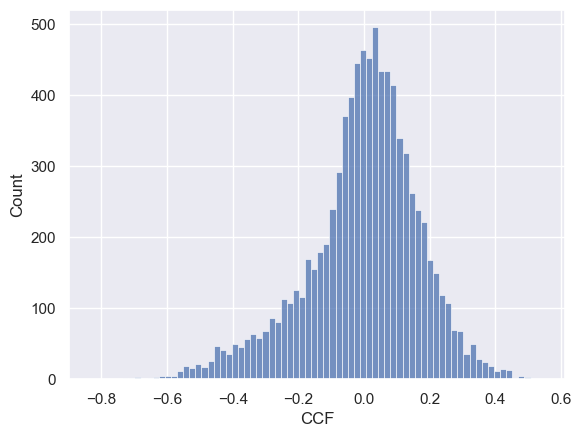

In [71]:
# Plotting the distribution of the residuals.
sns.histplot(ead_Y_test - y_hat_test_ead)

In [72]:
# Descriptive statisics for the values of a column.
pd.DataFrame(y_hat_test_ead).describe()

,0
count,8648.000000
mean,0.736497
std,0.104487
min,0.385745
25%,0.663073
50%,0.732534
75%,0.810746
max,1.008400


In [73]:
# Setting predicted values that are greater than 1 to 1 and vice versa
y_hat_test_ead = np.where(y_hat_test_ead < 0, 0, y_hat_test_ead)
y_hat_test_ead = np.where(y_hat_test_ead > 1, 1, y_hat_test_ead)

In [74]:
# some descriptive statisics for the values of a column.
pd.DataFrame(y_hat_test_ead).describe()

,0
count,8648.000000
mean,0.736496
std,0.104484
min,0.385745
25%,0.663073
50%,0.732534
75%,0.810746
max,1.000000


## III. Expected Loss

In [75]:
#cleaning the memory
loan_data_preprocessed_backup = []

loan_data_defaults = []
lgd_X_S1_train, lgd_X_S1_test, lgd_Y_S1_train, lgd_Y_S1_test  = [], [],[],[]
lgd_step_2_data =[]
lgd_X_S2_train, lgd_X_S2_test, lgd_Y_S2_train, lgd_Y_S2_test = [],[],[],[]
ead_X_train, ead_X_test, ead_Y_train, ead_Y_test = [], [], [], []

In [76]:
# filling the missing values with zeroes.
loan_data_preprocessed['mths_since_last_delinq'].fillna(0, inplace = True)
loan_data_preprocessed['mths_since_last_record'].fillna(0, inplace = True)

In [77]:
# keeping the variables only we need for the model.
loan_data_preprocessed_lgd_ead = loan_data_preprocessed[features_all]
# removing the dummy variable ref cats.
loan_data_preprocessed_lgd_ead = loan_data_preprocessed_lgd_ead.drop(features_reference_cat, axis = 1)

In [78]:
### 1- LGD MODELS ###
# using step 1 LGD model to calculate predicted values.
loan_data_preprocessed['recovery_rate_st_1'] = reg_lgd_st_1.model.predict(loan_data_preprocessed_lgd_ead)
# using step 2 LGD model to calculate predicted values.
loan_data_preprocessed['recovery_rate_st_2'] = reg_lgd_st_2.predict(loan_data_preprocessed_lgd_ead)

In [79]:
# Combining the predicted values from steps 1 + 2 to determine the final estimated recovery rate.
loan_data_preprocessed['recovery_rate'] = loan_data_preprocessed['recovery_rate_st_1'] * loan_data_preprocessed['recovery_rate_st_2']
# Setting estimated recovery rates greater than 1 to 1 and vice versa
loan_data_preprocessed['recovery_rate'] = np.where(loan_data_preprocessed['recovery_rate'] < 0, 0, loan_data_preprocessed['recovery_rate'])
loan_data_preprocessed['recovery_rate'] = np.where(loan_data_preprocessed['recovery_rate'] > 1, 1, loan_data_preprocessed['recovery_rate'])

In [80]:
# Calculating estimated LGD. Estimated LGD equals 1 - estimated recovery rate.
loan_data_preprocessed['LGD'] = 1 - loan_data_preprocessed['recovery_rate']
# Some descriptive statisics
loan_data_preprocessed['LGD'].describe()

count    466285.000000
mean          0.927798
std           0.058306
min           0.321313
25%           0.877417
50%           0.907894
75%           1.000000
max           1.000000
Name: LGD, dtype: float64

In [81]:
### 2- EAD MODEL ###
# Applying EAD model to calculate estimated credit conversion factor.
loan_data_preprocessed['CCF'] = reg_ead.predict(loan_data_preprocessed_lgd_ead)

In [82]:
# Setting estimated CCF that are greater than 1 to 1 and vice versa
loan_data_preprocessed['CCF'] = np.where(loan_data_preprocessed['CCF'] < 0, 0, loan_data_preprocessed['CCF'])
loan_data_preprocessed['CCF'] = np.where(loan_data_preprocessed['CCF'] > 1, 1, loan_data_preprocessed['CCF'])


In [83]:
# Estimated EAD = estimated CCF multiplied by funded amount.
loan_data_preprocessed['EAD'] = loan_data_preprocessed['CCF'] * loan_data_preprocessed_lgd_ead['funded_amnt']
# Some descriptive statisics
loan_data_preprocessed['EAD'].describe()


count    466285.000000
mean      10799.244078
std        6911.759776
min         188.614188
25%        5498.707476
50%        9206.184808
75%       14664.481611
max       35000.000000
Name: EAD, dtype: float64

In [84]:
### 3- PD MODEL ###
# Importing data to apply the PD model.
loan_data_inputs_train = pd.read_csv('loan_data_inputs_train.csv')
loan_data_inputs_test = pd.read_csv('loan_data_inputs_test.csv')

In [85]:
# Concating the two dfs
loan_data_inputs_pd = pd.concat([loan_data_inputs_train, loan_data_inputs_test], axis = 0)
# #clearing memeory
loan_data_inputs_train, loan_data_inputs_test = [],[] 

In [86]:
loan_data_inputs_pd.shape

(466285, 314)

In [87]:
loan_data_inputs_pd.head()

,Unnamed: 0.1,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,...,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
0,427211,427211,12796369,14818505,24000,24000,24000.0,36 months,8.90,762.08,...,1,0,0,1,0,0,0,0,0,0
1,206088,206088,1439740,1691948,10000,10000,10000.0,36 months,14.33,343.39,...,0,0,0,1,0,0,0,0,0,0
2,136020,136020,5214749,6556909,20425,20425,20425.0,36 months,8.90,648.56,...,0,0,0,1,0,0,0,0,0,0
3,412305,412305,13827698,15890016,17200,17200,17200.0,36 months,16.59,609.73,...,0,0,0,1,0,0,0,0,0,0
4,36159,36159,422455,496525,8400,8400,7450.0,36 months,12.84,282.40,...,0,1,0,1,0,0,0,0,0,0


In [88]:
# Setting the index 
loan_data_inputs_pd = loan_data_inputs_pd.set_index('Unnamed: 0')
loan_data_inputs_pd.head()

,Unnamed: 0.1,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
427211,427211,12796369,14818505,24000,24000,24000.0,36 months,8.90,762.08,A,...,1,0,0,1,0,0,0,0,0,0
206088,206088,1439740,1691948,10000,10000,10000.0,36 months,14.33,343.39,C,...,0,0,0,1,0,0,0,0,0,0
136020,136020,5214749,6556909,20425,20425,20425.0,36 months,8.90,648.56,A,...,0,0,0,1,0,0,0,0,0,0
412305,412305,13827698,15890016,17200,17200,17200.0,36 months,16.59,609.73,D,...,0,0,0,1,0,0,0,0,0,0
36159,36159,422455,496525,8400,8400,7450.0,36 months,12.84,282.40,C,...,0,1,0,1,0,0,0,0,0,0


In [89]:
# Here we select a limited set of input variables                                           
features_all_pd = ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
#'mths_since_earliest_cr_line:<140',
#'mths_since_earliest_cr_line:141-164',
#'mths_since_earliest_cr_line:165-247',
#'mths_since_earliest_cr_line:248-270',
#'mths_since_earliest_cr_line:271-352',
#'mths_since_earliest_cr_line:>352',
#'delinq_2yrs:0',
#'delinq_2yrs:1-3',
#'delinq_2yrs:>=4',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
#'open_acc:0',
#'open_acc:1-3',
#'open_acc:4-12',
#'open_acc:13-17',
#'open_acc:18-22',
#'open_acc:23-25',
#'open_acc:26-30',
#'open_acc:>=31',
'pub_rec:0-2',
'pub_rec:3-4',
'pub_rec:>=5',
#'total_acc:<=27',
#'total_acc:28-51',
#'total_acc:>=52',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'total_rev_hi_lim:<=5K',
'total_rev_hi_lim:5K-10K',
'total_rev_hi_lim:10K-20K',
'total_rev_hi_lim:20K-30K',
'total_rev_hi_lim:30K-40K',
'total_rev_hi_lim:40K-55K',
'total_rev_hi_lim:55K-95K',
'total_rev_hi_lim:>95K',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-120K',
'annual_inc:120K-140K',
'annual_inc:>140K',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
#'mths_since_last_delinq:Missing',
#'mths_since_last_delinq:0-3',
#'mths_since_last_delinq:4-30',
#'mths_since_last_delinq:31-56',
#'mths_since_last_delinq:>=57',
#'mths_since_last_record:Missing',
#'mths_since_last_record:0-2',
#'mths_since_last_record:3-20',
#'mths_since_last_record:21-31',
#'mths_since_last_record:32-80',
#'mths_since_last_record:81-86',
#'mths_since_last_record:>=86',
]

In [90]:
# Here we store the names of the reference category dummy variables in a list.
ref_categories_pd = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'int_rate:>20.281',
#'mths_since_earliest_cr_line:<140',
#'delinq_2yrs:>=4',
'inq_last_6mths:>6',
#'open_acc:0',
'pub_rec:0-2',
#'total_acc:<=27',
'acc_now_delinq:0',
'total_rev_hi_lim:<=5K',
'annual_inc:<20K',
'dti:>35'
#'mths_since_last_delinq:0-3',
#'mths_since_last_record:0-2'
]

In [91]:
# keeping the variables that we need for the PD model.
loan_data_inputs_pd_temp = loan_data_inputs_pd[features_all_pd]
# removing the dummy variable reference categories.
loan_data_inputs_pd_temp = loan_data_inputs_pd_temp.drop(ref_categories_pd, axis = 1)

In [92]:
loan_data_inputs_pd_temp.shape

(466285, 71)

In [93]:
# Importing the PD model, stored in second notebook
reg_pd = pickle.load(open('pd_model.sav', 'rb'))
# applying the PD model -  estimated default probabilities
loan_data_inputs_pd['PD'] = reg_pd.model.predict_proba(loan_data_inputs_pd_temp)[: ][: , 0]
# Some descriptive stats
loan_data_inputs_pd['PD'].describe()

count    466285.000000
mean          0.109344
std           0.064413
min           0.009093
25%           0.060447
50%           0.097445
75%           0.144815
max           0.659256
Name: PD, dtype: float64

In [94]:
# Concanating the dfs of LGD and EAD with the one of PD
loan_data_preprocessed_new = pd.concat([loan_data_preprocessed, loan_data_inputs_pd], axis = 1)
# Keeping necessary colomns for memory
loan_data_preprocessed_new = loan_data_preprocessed_new[['funded_amnt', 'PD', 'LGD', 'EAD']] 
# Cleaning memory
loan_data_preprocessed, loan_data_inputs_pd = [],[] 

In [95]:
loan_data_preprocessed_new.shape

(466285, 5)

In [96]:
# Calculating Expected Loss. EL = PD * LGD * EAD.
loan_data_preprocessed_new['EL'] = loan_data_preprocessed_new['PD'] * loan_data_preprocessed_new['LGD'] * loan_data_preprocessed_new['EAD']
# Some descriptive statisics for the values of a column.
loan_data_preprocessed_new['EL'].describe()

count    466285.000000
mean       1099.174141
std        1068.590336
min           9.172328
25%         377.690105
50%         728.548613
75%        1440.217344
max       11867.675016
Name: EL, dtype: float64

In [97]:
loan_data_preprocessed_new[['funded_amnt', 'PD', 'LGD', 'EAD', 'EL']].head()

,funded_amnt,funded_amnt,PD,LGD,EAD,EL
427211,24000,24000,0.034156,1.000000,16098.746413,549.868699
206088,10000,10000,0.081096,0.897945,6543.429629,476.491675
136020,20425,20425,0.037473,0.907296,12536.060878,426.216631
412305,17200,17200,0.231031,0.880072,13709.024966,2787.371709
36159,8400,8400,0.164986,0.891743,5091.514864,749.091781


In [98]:
loan_data_preprocessed_new['funded_amnt'].describe()

,funded_amnt,funded_amnt
count,466285.000000,466285.000000
mean,14291.801044,14291.801044
std,8274.371300,8274.371300
min,500.000000,500.000000
25%,8000.000000,8000.000000
50%,12000.000000,12000.000000
75%,20000.000000,20000.000000
max,35000.000000,35000.000000


In [99]:
# Total Expected Loss for All Loans calculated below
loan_data_preprocessed_new['EL'].sum()

512528414.2973925

In [100]:
# Total funded amount for all loans calculated below
loan_data_preprocessed_new['funded_amnt'].sum()

funded_amnt    6664052450
funded_amnt    6664052450
dtype: int64

In [101]:
# Total expected loss divided by total funded amount for all loans.
loan_data_preprocessed_new['EL'].sum() / loan_data_preprocessed_new['funded_amnt'].sum()

funded_amnt    0.076909
funded_amnt    0.076909
dtype: float64

Total expected loss divided by total funded amount for all loans is equal to **7.7%**